# Vector Space Model — Embedding & Semantic Search

> **Đồ án cuối kỳ NLP**

## Mục lục
1. [Giới thiệu Dataset & Mô hình](#1-giới-thiệu-dataset--mô-hình)
2. [EDA — Phân tích khám phá dữ liệu](#2-eda--phân-tích-khám-phá-dữ-liệu)
3. [Model — Xây dựng & đánh giá mô hình](#3-model--xây-dựng--đánh-giá-mô-hình)
4. [Tổng hợp & Định hướng](#4-tổng-hợp--định-hướng)

---

_(Sườn bài — nội dung chi tiết sẽ điền sau)_

# 1. Giới thiệu Dataset & Mô hình

## 1.1. Tổng quan Dataset
- Tên dataset:
- Nguồn / cách thu thập:
- Kích thước (số mẫu, số cột):
- Mô tả các trường dữ liệu:
- Bài toán hướng tới (semantic search / retrieval / similarity):

## 1.2. Giới thiệu các mô hình

### 1.2.1. E5 Embedding — `intfloat/e5-small-v2`
- Kiến trúc & ý tưởng chính:
- Đặc điểm (prefix `query:` / `passage:`, kích thước embedding...):
- Ưu / nhược điểm:

### 1.2.2. Sentence Transformers — `sentence-transformers/all-MiniLM-L6-v2`
- Kiến trúc & ý tưởng chính:
- Đặc điểm (kích thước embedding, tốc độ...):
- Ưu / nhược điểm:

### 1.2.3. So sánh nhanh 2 mô hình
| Tiêu chí | e5-small-v2 | all-MiniLM-L6-v2 |
|---|---|---|
| Số chiều embedding |  |  |
| Kích thước mô hình |  |  |
| Yêu cầu prefix |  |  |
| Ghi chú |  |  |

# 2. EDA — Phân tích khám phá dữ liệu

## 2.1. Tải & quan sát dữ liệu
- Đọc dữ liệu, xem `head()`, `info()`, `describe()`

## 2.2. Kiểm tra chất lượng dữ liệu
- Giá trị thiếu (missing values)
- Trùng lặp (duplicates)
- Phân bố nhãn / lớp (nếu có)

## 2.3. Phân tích văn bản
- Phân bố độ dài văn bản (số ký tự / số từ)
- Từ phổ biến / word cloud
- Nhận xét rút ra cho bước tiền xử lý

In [60]:
import os, sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from apps.services.data_loader import load_anime

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 70)

df_eda = load_anime()

# ── 2.1. Quan sát dữ liệu ──────────────────────────────────────────────────
print(f"Shape: {df_eda.shape}")
display(df_eda[["anime_id", "name", "genre", "type", "episodes", "rating", "members"]].head(5))


Shape: (12294, 9)


,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Military, Shounen",TV,64,9.26,793665
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, Sci-Fi, Shounen",TV,51,9.25,114262
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24,9.17,673572
4,9969,Gintama',"Action, Comedy, Historical, Parody, Samurai, Sci-Fi, Shounen",TV,51,9.16,151266


In [61]:
print("=== df.info() ===")
df_eda.info()
print("\n=== df.describe() ===")
display(df_eda[["rating", "members", "episodes"]].describe())


=== df.info() ===
<class 'pandas.DataFrame'>
RangeIndex: 12294 entries, 0 to 12293
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   anime_id   12294 non-null  int64  
 1   name       12294 non-null  str    
 2   genre      12294 non-null  str    
 3   type       12294 non-null  str    
 4   episodes   12294 non-null  str    
 5   rating     12064 non-null  float64
 6   members    12294 non-null  int64  
 7   document   12294 non-null  str    
 8   genre_set  12294 non-null  object 
dtypes: float64(1), int64(2), object(1), str(5)
memory usage: 864.6+ KB

=== df.describe() ===


,rating,members
count,12064.000000,1.229400e+04
mean,6.473902,1.807134e+04
std,1.026746,5.482068e+04
min,1.670000,5.000000e+00
25%,5.880000,2.250000e+02
50%,6.570000,1.550000e+03
75%,7.180000,9.437000e+03
max,10.000000,1.013917e+06


In [62]:
# ── 2.2. Kiểm tra chất lượng dữ liệu ─────────────────────────────────────
print("=== Missing values ===")
missing = df_eda.isnull().sum()
missing_pct = (missing / len(df_eda) * 100).round(2)
display(pd.DataFrame({"missing_count": missing, "missing_%": missing_pct})[missing > 0])

print(f"\n=== Duplicates ===")
dup_name = df_eda.duplicated(subset=["name"]).sum()
print(f"Trùng tên anime: {dup_name}")
print(f"Trùng anime_id : {df_eda.duplicated(subset=['anime_id']).sum()}")

print(f"\n=== Rating distribution ===")
print(f"rating NaN: {df_eda['rating'].isna().sum()} / {len(df_eda)}")
print(f"rating range: [{df_eda['rating'].min():.2f}, {df_eda['rating'].max():.2f}]")


=== Missing values ===


,missing_count,missing_%
rating,230,1.87



=== Duplicates ===
Trùng tên anime: 2
Trùng anime_id : 0

=== Rating distribution ===
rating NaN: 230 / 12294
rating range: [1.67, 10.00]


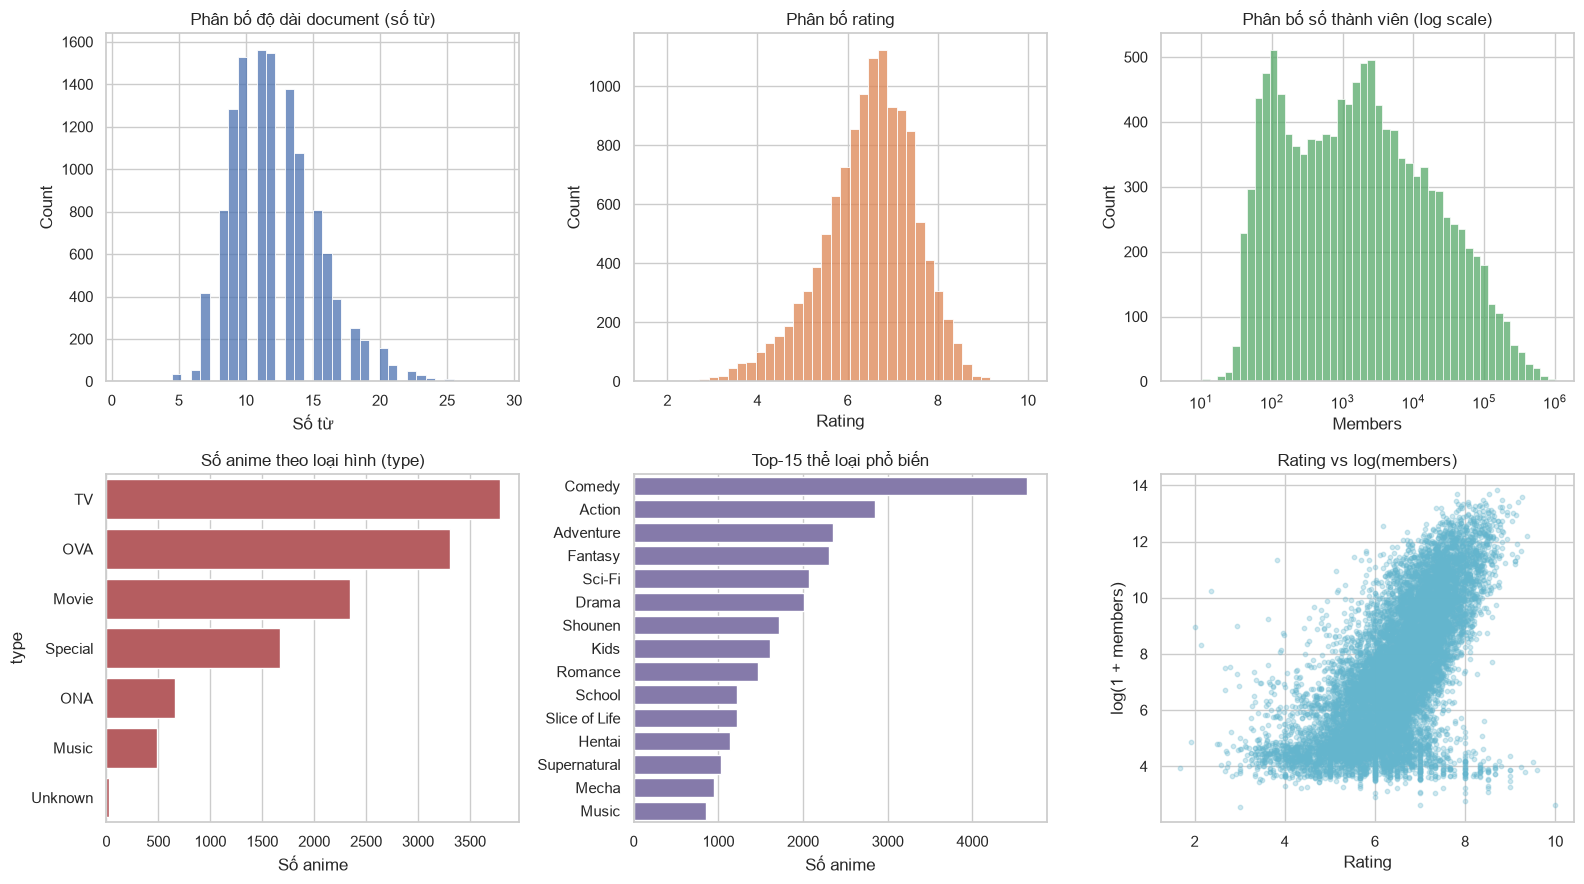


Độ dài document (từ): min=1, max=29, mean=12.2, median=12


In [63]:
# ── 2.3. Phân tích văn bản ────────────────────────────────────────────────
df_eda["doc_len_chars"] = df_eda["document"].str.len()
df_eda["doc_len_words"] = df_eda["document"].str.split().map(len)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# (a) Phân bố độ dài document (số từ)
sns.histplot(df_eda["doc_len_words"], bins=40, ax=axes[0, 0], color="#4C72B0")
axes[0, 0].set_title("Phân bố độ dài document (số từ)")
axes[0, 0].set_xlabel("Số từ")

# (b) Phân bố rating
sns.histplot(df_eda["rating"].dropna(), bins=40, ax=axes[0, 1], color="#DD8452")
axes[0, 1].set_title("Phân bố rating")
axes[0, 1].set_xlabel("Rating")

# (c) Phân bố members (log scale)
sns.histplot(df_eda["members"], bins=50, log_scale=True, ax=axes[0, 2], color="#55A868")
axes[0, 2].set_title("Phân bố số thành viên (log scale)")
axes[0, 2].set_xlabel("Members")

# (d) Số anime theo type
type_counts = df_eda["type"].replace("", "Unknown").value_counts()
sns.barplot(x=type_counts.values, y=type_counts.index, ax=axes[1, 0], color="#C44E52")
axes[1, 0].set_title("Số anime theo loại hình (type)")
axes[1, 0].set_xlabel("Số anime")

# (e) Top-15 thể loại phổ biến
all_genres = [g.strip() for genres in df_eda["genre"] for g in genres.split(",") if g.strip()]
genre_counts = Counter(all_genres).most_common(15)
g_labels, g_vals = zip(*genre_counts)
sns.barplot(x=list(g_vals), y=list(g_labels), ax=axes[1, 1], color="#8172B2")
axes[1, 1].set_title("Top-15 thể loại phổ biến")
axes[1, 1].set_xlabel("Số anime")

# (f) rating vs members
axes[1, 2].scatter(df_eda["rating"], np.log1p(df_eda["members"]),
                   alpha=0.3, s=10, color="#64B5CD")
axes[1, 2].set_title("Rating vs log(members)")
axes[1, 2].set_xlabel("Rating")
axes[1, 2].set_ylabel("log(1 + members)")

plt.tight_layout()
plt.show()

print(f"\nĐộ dài document (từ): min={df_eda['doc_len_words'].min()}, "
      f"max={df_eda['doc_len_words'].max()}, "
      f"mean={df_eda['doc_len_words'].mean():.1f}, "
      f"median={df_eda['doc_len_words'].median():.0f}")


# 3. Model — Xây dựng & đánh giá mô hình

Mục này xây dựng **Vector Space Model** cho tìm kiếm ngữ nghĩa anime và **so sánh 2 embedding model**: `intfloat/e5-small-v2` và `sentence-transformers/all-MiniLM-L6-v2`. Pipeline tái sử dụng các service trong package `apps/` (chính là các service FastAPI dùng).

> **Điều kiện tiên quyết** — chạy ở terminal, mỗi lệnh 1 lần:
> 1. Bật Milvus: `docker compose up -d`
> 2. Tải model về local: `python -m apps.cli pull-models`
> 3. Import dữ liệu vào Milvus: `python -m apps.cli import-data`


## 3.0. Thiết lập môi trường & nạp dữ liệu

Import thư viện, thêm `apps/` vào `sys.path`, nạp dataset anime và xem trước vài dòng.


In [64]:

%pip install matplotlib
%pip install seaborn
%pip install pydantic_settings
%pip install pymilvus
%pip install sentence-transformers
import os
import sys
import time
from pathlib import Path

os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")

# Cho phép import package `apps` (các service dùng chung với FastAPI)
PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from apps.config import MODEL_REGISTRY
from apps.services.data_loader import load_anime
from apps.services import milvus_store, search_service, evaluation
from apps.services.embedding import get_model

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 70)

MODELS = ["e5-small-v2", "all-MiniLM-L6-v2"]
TOP_K = 10

df = load_anime()
print(f"Tổng số anime (document): {len(df):,}")
df[["anime_id", "name", "genre", "type", "episodes", "rating", "members", "document"]].head()


[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Tổng số anime (document): 12,294


,anime_id,name,genre,type,episodes,rating,members,document
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630,"Kimi no Na wa. Genres: Drama, Romance, School, Supernatural. Type:..."
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Military, Shounen",TV,64,9.26,793665,"Fullmetal Alchemist: Brotherhood Genres: Action, Adventure, Drama,..."
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, Sci-Fi, Shounen",TV,51,9.25,114262,"Gintama° Genres: Action, Comedy, Historical, Parody, Samurai, Sci-..."
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24,9.17,673572,"Steins;Gate Genres: Sci-Fi, Thriller. Type: TV. Episodes: 24."
4,9969,Gintama',"Action, Comedy, Historical, Parody, Samurai, Sci-Fi, Shounen",TV,51,9.16,151266,"Gintama' Genres: Action, Comedy, Historical, Parody, Samurai, Sci-..."


In [65]:
# Đảm bảo dữ liệu đã có trong Milvus — KHÔNG re-import khi chạy lại notebook (tránh tốn tài nguyên).
#   • Mặc định chỉ import nếu collection đang rỗng (idempotent, không trùng lặp).
#   • Muốn ép nạp lại: đặt FORCE_IMPORT = True, hoặc chạy `python -m apps.cli import-data -f`.
FORCE_IMPORT = False

for mk in MODELS:
    n = milvus_store.count(mk)
    if n > 0 and not FORCE_IMPORT:
        print(f"[{mk}] đã có {n:,} vector trong Milvus -> bỏ qua import.")
    else:
        print(f"[{mk}] collection rỗng -> đang import...")
        print("   ", search_service.ensure_imported(mk, df=df, force=FORCE_IMPORT))

2026-06-18 23:30:56,076 [ERROR][_log_rpc_error]: Unexpected error: [has_collection], Cannot invoke RPC on closed channel!, <elapsed:0.3ms>
Traceback:
Traceback (most recent call last):
  File "/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pymilvus/decorators.py", line 518, in handler
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pymilvus/decorators.py", line 565, in handler
    return func(self, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pymilvus/decorators.py", line 458, in handler
    raise e from e
  File "/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pymilvus/decorators.py", line 419, in handler
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/Library/Frameworks/Python.framework/Versi

MilvusException: <MilvusException: (code=1, message=Unexpected error, message=<Cannot invoke RPC on closed channel!>)>

## 3.1. Tiền xử lý & chuẩn bị dữ liệu

Mỗi anime được ghép thành một *document* (`tên + thể loại + loại hình + số tập`) — đơn vị văn bản đưa vào không gian vector. Bên dưới khảo sát phân bố độ dài document và loại hình.


In [ ]:
print("Ví dụ document đưa vào embedding:")
for doc in df["document"].head(5):
    print("  •", doc)

# Phân bố độ dài document (số từ)
df["doc_len"] = df["document"].str.split().map(len)
display(df["doc_len"].describe().to_frame("doc_len (số từ)").T)

fig, ax = plt.subplots(1, 2, figsize=(12, 3.2))
sns.histplot(df["doc_len"], bins=40, ax=ax[0], color="#4C72B0")
ax[0].set_title("Phân bố độ dài document (số từ)")
ax[0].set_xlabel("Số từ"); ax[0].set_ylabel("Số anime")

top_types = df["type"].replace("", "Unknown").value_counts()
sns.barplot(x=top_types.values, y=top_types.index, ax=ax[1], color="#55A868")
ax[1].set_title("Số lượng anime theo loại hình (type)")
ax[1].set_xlabel("Số anime")
plt.tight_layout(); plt.show()

## 3.2. Mô hình, Hàm mất mát & Chỉ số đánh giá

### 3.2.1. Tổng quan 3 mô hình

| Mô hình | Loại | Chiều vector | Mô tả |
|---|---|---|---|
| **TF-IDF** | Sparse / Lexical | ~20 000 (vocab) | Baseline truyền thống; không cần training; nhạy với keyword chính xác |
| **E5-small-v2** | Dense / Semantic | 384 | Fine-tuned với contrastive learning; yêu cầu prefix `query:` / `passage:` |
| **all-MiniLM-L6-v2** | Dense / Semantic | 384 | Distilled từ MiniLM-L12; cân bằng tốc độ và chất lượng ngữ nghĩa |

---

### 3.2.2. Hàm mất mát (Loss Function)

**TF-IDF** không có quá trình huấn luyện — đây là phương pháp thống kê thuần túy.

**E5-small-v2** được huấn luyện với **InfoNCE (Contrastive Loss)**:

$$\mathcal{L}_{\text{InfoNCE}} = -\log \frac{\exp(\text{sim}(q, d^+)/\tau)}{\sum_{j=1}^{N} \exp(\text{sim}(q, d_j)/\tau)}$$

Trong đó $q$ là query, $d^+$ là positive passage, $d_j$ là các in-batch negatives, và $\tau$ là temperature.

**all-MiniLM-L6-v2** được huấn luyện với **Multiple Negatives Ranking Loss (MNRL)**, kết hợp với **MSE distillation** từ teacher model lớn hơn:

$$\mathcal{L}_{\text{MNRL}} = -\frac{1}{N}\sum_{i=1}^{N} \log \frac{\exp(\text{sim}(q_i, d_i^+))}{\sum_{j=1}^{N} \exp(\text{sim}(q_i, d_j))}$$

---

### 3.2.3. Độ tương đồng (Similarity)

Cả 3 mô hình đều dùng **Cosine Similarity** để xếp hạng kết quả truy vấn:

$$\text{cos}(\mathbf{u}, \mathbf{v}) = \frac{\mathbf{u} \cdot \mathbf{v}}{\|\mathbf{u}\| \cdot \|\mathbf{v}\|}$$

---

### 3.2.4. Chỉ số đánh giá (Evaluation Metrics)

Vì dataset không có nhãn liên quan, **ground-truth giả lập** được xây dựng dựa trên độ trùng thể loại Jaccard ≥ 0.5:

$$\text{Jaccard}(A, B) = \frac{|A \cap B|}{|A \cup B|}$$

**Precision@K** — Tỉ lệ kết quả liên quan trong top-K:

$$\text{P@K} = \frac{|\{d \in \text{top-}K : d \in \text{Rel}\}|}{K}$$

**Recall@K** — Tỉ lệ tài liệu liên quan được tìm thấy trong top-K:

$$\text{R@K} = \frac{|\{d \in \text{top-}K : d \in \text{Rel}\}|}{|\text{Rel}|}$$

**MRR (Mean Reciprocal Rank)** — Đánh giá thứ hạng của kết quả liên quan đầu tiên:

$$\text{MRR} = \frac{1}{|Q|} \sum_{q \in Q} \frac{1}{\text{rank}_q^+}$$

**nDCG@K (Normalized Discounted Cumulative Gain)** — Xem xét cả thứ hạng và mức độ liên quan:

$$\text{nDCG@K} = \frac{\text{DCG@K}}{\text{IDCG@K}}, \quad \text{DCG@K} = \sum_{i=1}^{K} \frac{\text{rel}_i}{\log_2(i+1)}$$

| Metric | Ý nghĩa | Phạm vi |
|---|---|---|
| Precision@K | Chính xác trong top-K | [0, 1] |
| Recall@K | Bao phủ tài liệu liên quan | [0, 1] |
| MRR | Tốc độ tìm đúng kết quả đầu tiên | [0, 1] |
| nDCG@K | Chất lượng xếp hạng tổng thể | [0, 1] |


In [ ]:
"""Minh hoạ tính toán cho phần 3.2: TF-IDF, Cosine Similarity, và Evaluation Metrics."""
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# ── 3.2.1 Ví dụ tính TF-IDF ─────────────────────────────────────────────
sample_docs = [
    "Naruto action adventure ninja magic",
    "Bleach action adventure soul reaper",
    "Clannad romance drama school slice of life",
    "Toradora romance comedy school",
    "Death Note thriller mystery psychological",
]
query = "action adventure magic"

vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(sample_docs)
query_vec = vectorizer.transform([query])

print("=== TF-IDF matrix (5 docs × {} terms) ===".format(len(vectorizer.vocabulary_)))
tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=vectorizer.get_feature_names_out(),
    index=[f"doc{i+1}" for i in range(len(sample_docs))]
)
display(tfidf_df.style.background_gradient(cmap="Blues").format("{:.3f}"))

# ── 3.2.3 Cosine Similarity ───────────────────────────────────────────────
print("\n=== Cosine similarity (query vs docs) ===")
scores = cosine_similarity(query_vec, tfidf_matrix).flatten()
for doc, score in sorted(zip(sample_docs, scores), key=lambda x: -x[1]):
    print(f"  {score:.4f}  |  {doc}")

# ── 3.2.4 Tính thủ công Precision@K, Recall@K, MRR, nDCG@K ─────────────
print("\n=== Evaluation Metrics (K=3) ===")
K = 3
# Giả sử doc1, doc2 là liên quan (action/adventure)
relevant_set = {0, 1}
ranked = np.argsort(-scores)  # index theo thứ tự giảm dần score

top_k_idx = ranked[:K]
hits = [1 if i in relevant_set else 0 for i in top_k_idx]

precision_at_k = sum(hits) / K
recall_at_k = sum(hits) / len(relevant_set)

# MRR: rank của kết quả liên quan đầu tiên
mrr = 0.0
for rank, idx in enumerate(ranked, start=1):
    if idx in relevant_set:
        mrr = 1.0 / rank
        break

# nDCG@K
dcg = sum(rel / np.log2(i + 2) for i, rel in enumerate(hits))
ideal_hits = sorted(hits, reverse=True)
idcg = sum(rel / np.log2(i + 2) for i, rel in enumerate(ideal_hits))
ndcg_at_k = dcg / idcg if idcg > 0 else 0.0

metrics_df = pd.DataFrame([{
    f"Precision@{K}": round(precision_at_k, 4),
    f"Recall@{K}":    round(recall_at_k, 4),
    "MRR":            round(mrr, 4),
    f"nDCG@{K}":     round(ndcg_at_k, 4),
}])
display(metrics_df)
print(f"Top-{K} retrieved: {[sample_docs[i] for i in top_k_idx]}")
print(f"Relevant docs    : {[sample_docs[i] for i in relevant_set]}")


## 3.3. Baseline: Mô hình Vector Space Model bằng TF-IDF

Trước khi sử dụng các mô hình dense embedding, nhóm xây dựng một mô hình Vector Space Model truyền thống bằng TF-IDF.

Trong baseline này, mỗi anime được xem như một document. Document này sẽ được chuyển thành một vector thưa, trong đó mỗi chiều của vector tương ứng với một từ hoặc một cụm từ n-gram trong bộ từ vựng.

TF-IDF gán trọng số cao hơn cho những từ quan trọng trong một document anime cụ thể, nhưng không xuất hiện quá phổ biến trong toàn bộ tập dữ liệu. Sau khi vector hóa, cosine similarity được sử dụng để xếp hạng các anime dựa trên mức độ tương đồng giữa anime và câu truy vấn.

Baseline này giúp nhóm so sánh phương pháp tìm kiếm vector truyền thống dựa trên keyword với các mô hình tìm kiếm ngữ nghĩa hiện đại sử dụng dense vector như MiniLM và E5.


In [ ]:
from apps.services.tfidf_search import TFIDFSearchService

tfidf_service = TFIDFSearchService(
    max_features=20000,
    ngram_range=(1, 2),
    min_df=2,
)

tfidf_service.fit(df, text_col="document")

print("TF-IDF baseline is ready.")
print("Number of anime:", tfidf_service.matrix.shape[0])
print("Vector dimensions:", tfidf_service.matrix.shape[1])

## 3.4. Sinh dense embedding & kho vector

So sánh tốc độ encode và đặc tính embedding của 2 dense model. Toàn bộ dense corpus đã được encode và lưu sẵn trong Milvus (qua `apps.cli import-data`).


In [ ]:
sample_docs = df["document"].head(500).tolist()
enc_rows = []
for mk in MODELS:
    m = get_model(mk)
    t0 = time.perf_counter()
    emb = m.encode_passages(sample_docs)
    dt = time.perf_counter() - t0
    enc_rows.append({
        "model": mk,
        "dim": emb.shape[1],
        "thời gian encode 500 doc (s)": round(dt, 2),
        "doc/giây": round(len(sample_docs) / dt, 1),
        "|v| (chuẩn L2)": round(float(np.linalg.norm(emb[0])), 3),
        "vector trong Milvus": milvus_store.count(mk),
        "collection": MODEL_REGISTRY[mk].collection,
    })
pd.DataFrame(enc_rows).set_index("model")

## 3.5. Vector Space Model & truy vấn

Người dùng nhập câu mô tả tự do (free-text); hệ thống encode câu truy vấn rồi xếp hạng anime theo **cosine similarity** trong Milvus.


In [ ]:
def show_results(results: list[dict]) -> pd.DataFrame:
    return pd.DataFrame([
        {
            "name": r["name"],
            "type": r.get("type"),
            "genre": r.get("genre"),
            "score": round(r["score"], 4),
        }
        for r in results
    ])

query = "epic fantasy adventure with magic"

print("TF-IDF baseline")
tfidf_results = tfidf_service.search(query, top_k=5)
display(show_results(tfidf_results))

for mk in MODELS:
    print(f"Dense embedding model: {mk}")
    results = search_service.search_text(mk, query, top_k=5)
    display(show_results(results))

### 3.5.1. Tìm anime tương tự & ma trận tương đồng

(1) *More-like-this*: dùng chính document của một anime làm truy vấn. (2) Trực quan hoá ma trận cosine giữa vài anime tiêu biểu.


In [ ]:
# (1) More-like-this
print("Anime tương tự 'Naruto' — TF-IDF baseline")
display(show_results(tfidf_service.search_similar_to_anime("Naruto", top_k=5)))

for mk in MODELS:
    print(f"Anime tương tự 'Naruto' — dense model: {mk}")
    res = search_service.search_similar_to_anime(mk, "Naruto", df, top_k=5)
    display(show_results(res))

# (2) Ma trận cosine similarity giữa vài anime tiêu biểu
titles = ["Naruto", "Bleach", "One Piece", "Death Note", "Clannad", "Toradora!", "Steins;Gate"]
sub = df[df["name"].isin(titles)].drop_duplicates("name")

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
for ax, mk in zip(axes, MODELS):
    emb = get_model(mk).encode_passages(sub["document"].tolist())
    sim = emb @ emb.T
    sns.heatmap(
        sim, annot=True, fmt=".2f", cmap="viridis",
        xticklabels=sub["name"], yticklabels=sub["name"], ax=ax, cbar=False,
    )
    ax.set_title(f"Cosine similarity — {mk}")
plt.tight_layout(); plt.show()

## 3.6. Đánh giá & so sánh 3 model

Dataset không có nhãn liên quan sẵn → xây **ground-truth giả lập**: hai anime "liên quan" nếu độ trùng thể loại `Jaccard(genre) ≥ 0.5`. Đo **Precision@K, Recall@K, MRR, nDCG@K** trên tập query ngẫu nhiên. TF-IDF chạy cosine similarity trên sparse matrix trong bộ nhớ; dense embedding tiếp tục truy vấn qua Milvus.


In [ ]:
GENRE_THRESHOLD = 0.5
eval_df = df[(df["genre_set"].map(len) >= 2) & (df["members"] >= 10000)].reset_index(drop=True)
print(f"Corpus đánh giá: {len(eval_df):,} anime")

rng = np.random.default_rng(42)
relevance = evaluation.build_relevance(eval_df, query_ids=None, threshold=GENRE_THRESHOLD)
candidate_ids = [aid for aid, rel in relevance.items() if rel]
query_ids = list(rng.choice(candidate_ids, size=min(300, len(candidate_ids)), replace=False))
print(f"Số query đánh giá: {len(query_ids)}  |  Top-K = {TOP_K}")

tfidf_row = evaluation.evaluate_tfidf_model(
    tfidf_service,
    relevance,
    query_ids,
    k=TOP_K,
)
dense_table = evaluation.compare_models(MODELS, eval_df, relevance, query_ids, k=TOP_K)
result_table = pd.concat([
    pd.DataFrame([tfidf_row]).set_index("model"),
    dense_table,
])
result_table

### 3.6.1. Trực quan hoá so sánh chất lượng & tốc độ


In [ ]:
metric_cols = [f"Precision@{TOP_K}", f"Recall@{TOP_K}", "MRR", f"nDCG@{TOP_K}"]
plot_df = result_table[metric_cols].T

fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
plot_df.plot(kind="bar", ax=ax[0], colormap="Set2", edgecolor="black")
ax[0].set_title("Chất lượng truy hồi (cao hơn = tốt hơn)")
ax[0].set_ylabel("Điểm"); ax[0].set_xticklabels(metric_cols, rotation=0)
ax[0].legend(title="model")
for c in ax[0].containers:
    ax[0].bar_label(c, fmt="%.3f", fontsize=8)

speed = result_table[["ms_per_query"]]
speed.plot(kind="barh", ax=ax[1], color="#C44E52", legend=False, edgecolor="black")
ax[1].set_title("Độ trễ trung bình mỗi truy vấn (thấp hơn = tốt hơn)")
ax[1].set_xlabel("ms / query")
for c in ax[1].containers:
    ax[1].bar_label(c, fmt="%.2f ms", fontsize=9)
plt.tight_layout(); plt.show()

## 3.7. Nhận xét & kết luận so sánh 3 model


# 4. Tổng hợp & Định hướng

## 4.1. Tổng hợp kết quả
- Bảng so sánh hiệu năng 2 mô hình
- Nhận xét chính

## 4.2. Hạn chế
- Hạn chế về dữ liệu / mô hình / phương pháp đánh giá

## 4.3. Định hướng phát triển
- Cải tiến mô hình / dữ liệu
- Hướng mở rộng tiếp theo